In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd

import kind
import ex_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample_nom', '122',
        '--data_nsample_exc', '528',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.9',

        '--back_nsample', '64',
        '--fore_nsample', '32',

        '--batch_size', '64',
        '--learning_rate', '0.002',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', '../../models/dreamer',

        '--rez_nsample_nom', '32',
        '--rez_nsample_exc', '16',
        '--embed_nom', '{"sin": 4, "cos": 4}',
        '--embed_exc', '{"data": 12}',
    ]
)

setpoint = [1.0, 0.0]

In [3]:
model = kind.model(args)

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_index, args.file_ext,
    args.data_nsample_nom, args.data_nsample_exc,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.back_nsample, args.fore_nsample), setpoint, load_normalized=True)

training = kind.training(model)

In [4]:
_, _, data_loader = dataset.load(data_type='mixed')

data_path = '../../data/dreamer/duffing_all_0.csv'
dataframe = pd.read_csv(data_path, header=None, dtype=np.float32)
replay = torch.unsqueeze(torch.from_numpy(dataframe.to_numpy()), 0)
print(replay.shape)

torch.Size([1, 626, 4])


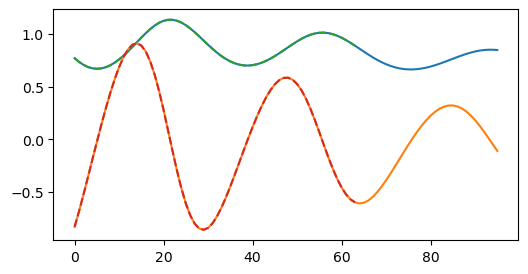

In [5]:
jdata = 3
offset = 90

with torch.no_grad():
    for back_n, fore_n in data_loader:
        true_n = torch.cat([back_n, fore_n], dim=1)

        true = replay[:, offset:offset + args.back_nsample + args.fore_nsample]
        back = replay[:, offset:offset + args.back_nsample]

        true = dataset.normalizer.normalize(true)
        back = dataset.normalizer.normalize(back)

        plt.figure(figsize=(6,3))
        plt.plot(true[0, :, :2])
        plt.plot(back[0, :, :2], linestyle='dashed')
        break

#print(tata.shape)

In [6]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=1.118238, valid=0.925808, test=0.987347
	validation loss decreased (inf -> 0.925808), saving model ...
	epoch 2 losses: train=1.083130, valid=0.923078, test=0.969978
	validation loss decreased (0.925808 -> 0.923078), saving model ...
	epoch 3 losses: train=1.055256, valid=0.915870, test=0.956037
	validation loss decreased (0.923078 -> 0.915870), saving model ...
	epoch 4 losses: train=1.035179, valid=0.911581, test=0.945424
	validation loss decreased (0.915870 -> 0.911581), saving model ...
	epoch 5 losses: train=1.018262, valid=0.908203, test=0.933986
	validation loss decreased (0.911581 -> 0.908203), saving model ...
	epoch 6 losses: train=0.999777, valid=0.905610, test=0.921402
	validation loss decreased (0.908203 -> 0.905610), saving model ...
	epoch 7 losses: train=0.979917, valid=0.904323, test=0.908623
	validation loss decreased (0.905610 -> 0.904323), saving model ...
	epoch 8 losses: train=0.959256, valid=0.903693, test=0.89

In [13]:
model.eval()
_, _, data_loader = dataset.load(data_type='nom')

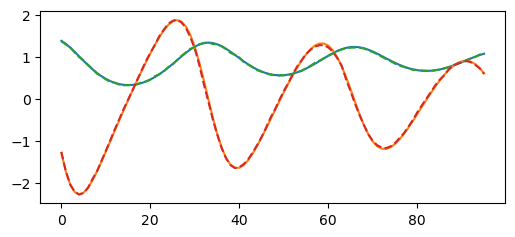

NameError: name 'tata' is not defined

In [15]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,2.5))
        plt.plot(true[jdata, :, :2])
        plt.plot(mean_nom[0, :, :2], linestyle='dashed')

        plt.show()

        break

#print(tata.shape)

In [19]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.236035, valid=0.270011, test=0.276491
	validation loss decreased (inf -> 0.270011), saving model ...
	epoch 2 losses: train=0.355803, valid=0.105032, test=0.215305
	validation loss decreased (0.270011 -> 0.105032), saving model ...
	epoch 3 losses: train=0.300395, valid=0.082297, test=0.174049
	validation loss decreased (0.105032 -> 0.082297), saving model ...
	epoch 4 losses: train=0.273370, valid=0.186755, test=0.154570
	early stopping counter: 1 out of 100
	epoch 5 losses: train=0.243489, valid=0.224778, test=0.163026
	early stopping counter: 2 out of 100
	epoch 6 losses: train=0.216542, valid=0.212566, test=0.201275
	early stopping counter: 3 out of 100
	epoch 7 losses: train=0.203930, valid=0.177126, test=0.221752
	early stopping counter: 4 out of 100
	epoch 8 losses: train=0.192561, valid=0.133225, test=0.219411
	early stopping counter: 5 out of 100
	epoch 9 losses: train=0.180976, valid=0.104818, test=0.219044
	early 

In [20]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

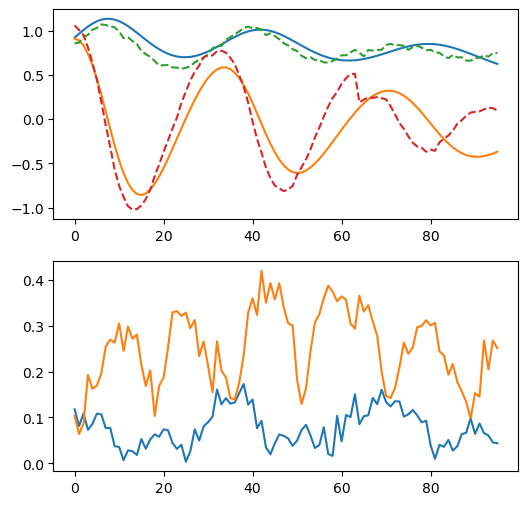

In [22]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_nom
        zeta_nom = model_o.zeta_nom

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(zeta_nom[0, :, :2])

        plt.show()

        break

#print(tata.shape)

In [28]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.041722, valid=0.037891, test=0.038937
	validation loss decreased (inf -> 0.037891), saving model ...
	epoch 2 losses: train=0.023254, valid=0.018685, test=0.021544
	validation loss decreased (0.037891 -> 0.018685), saving model ...
	epoch 3 losses: train=0.018707, valid=0.017479, test=0.018309
	validation loss decreased (0.018685 -> 0.017479), saving model ...
	epoch 4 losses: train=0.021104, valid=0.015111, test=0.022912
	validation loss decreased (0.017479 -> 0.015111), saving model ...
	epoch 5 losses: train=0.017364, valid=0.011210, test=0.019104
	validation loss decreased (0.015111 -> 0.011210), saving model ...
	epoch 6 losses: train=0.013458, valid=0.013285, test=0.014657
	early stopping counter: 1 out of 100
	epoch 7 losses: train=0.009774, valid=0.012180, test=0.011077
	early stopping counter: 2 out of 100
	epoch 8 losses: train=0.009956, valid=0.011960, test=0.007200
	early stopping counter: 3 out of 100
	epoch 9 losses

In [29]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

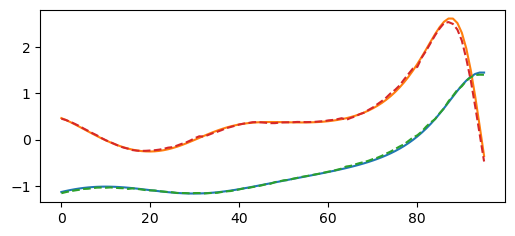

In [33]:
jdata = 3

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_exc

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [34]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.069436, valid=0.020326, test=0.065215
	validation loss decreased (inf -> 0.020326), saving model ...
	epoch 2 losses: train=0.049200, valid=0.017570, test=0.061265
	validation loss decreased (0.020326 -> 0.017570), saving model ...
	epoch 3 losses: train=0.043938, valid=0.012557, test=0.056942
	validation loss decreased (0.017570 -> 0.012557), saving model ...
	epoch 4 losses: train=0.042270, valid=0.008706, test=0.053714
	validation loss decreased (0.012557 -> 0.008706), saving model ...
	epoch 5 losses: train=0.036498, valid=0.006977, test=0.052005
	validation loss decreased (0.008706 -> 0.006977), saving model ...
	epoch 6 losses: train=0.033783, valid=0.005966, test=0.050768
	validation loss decreased (0.006977 -> 0.005966), saving model ...
	epoch 7 losses: train=0.035523, valid=0.004709, test=0.049320
	validation loss decreased (0.005966 -> 0.004709), saving model ...
	epoch 8 losses: train=0.033164, valid=0.003532, 

In [35]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

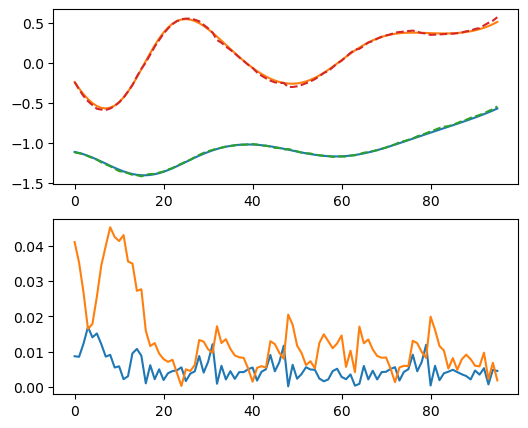

In [40]:
jdata = 3

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        exc = model_o.mean_exc
        exc_u = model_o.zeta_exc

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

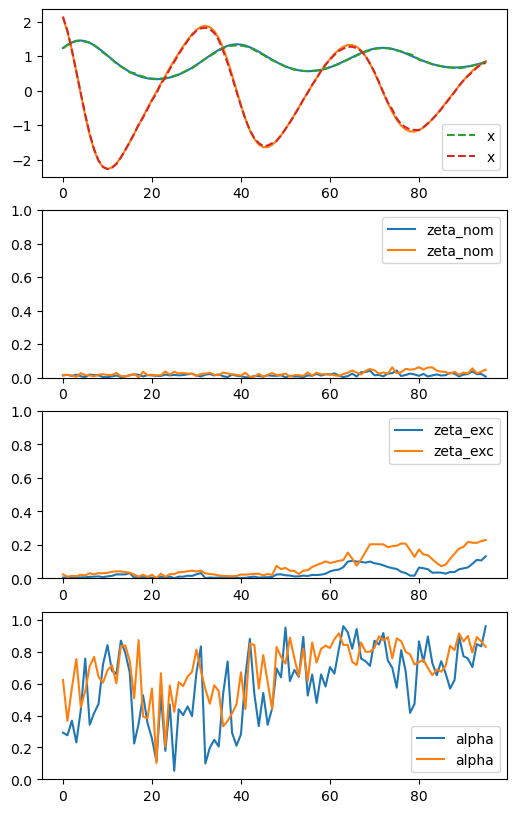

In [46]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pre = model_o.blend
        u_nom = model_o.zeta_nom
        u_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,10))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(u_nom[0, :, :2], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(u_exc[0, :, :2], label='zeta_exc')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break